01 — Exploratory Data Analysis

Building energy consumption on the ASHRAE GEPIII dataset. Before we touch a model,
we want to know what we are looking at: where the data comes from, how clean it is,
what the target looks like, how consumption changes through the day / week / year,
and how it responds to weather.

Everything in this notebook runs on the 4-site subset defined in
`configs/default.yaml`. That subset is enough to expose every pattern we care about
while staying small enough to iterate quickly. Running the same notebook with
`data.use_full: true` works without changes if you have the disk and patience.

What you will find here
1. Sample sizes, sites, and buildings
2. Building metadata: primary use, square footage, age
3. Missingness: which columns are missing how much, and where
4. Target distribution: raw vs. log1p, per-meter
5. Meter-type breakdown
6. Temporal patterns: hour, day-of-week, season
7. Weather and the U-shaped response to temperature
8. Sample time series for individual buildings
9. Outliers and zero-streaks
10. The train / validation split

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.data.clean import basic_clean, impute_weather
from src.data.load import load_subset, merge_with_context
from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT
from src.viz.eda_plots import (
    plot_target_distribution,
    plot_missingness,
    plot_meter_breakdown,
    plot_primary_use_breakdown,
    plot_hourly_profile,
    plot_weekly_profile,
    plot_temperature_vs_consumption,
    plot_correlation_matrix,
    plot_per_site_volume,
)

set_style()
PLOT_DIR = Path("../results/plots/eda")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
cfg = load_config("../configs/default.yaml")
print("Sites in subset:", cfg.data.site_subset)
print("Train months:", cfg.split.train_months)
print("Val months:", cfg.split.val_months)


Sites in subset: [2, 4, 13, 14]
Train months: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Val months: [10, 11, 12]


1. Loading the subset

`load_subset` filters the 20.2M-row training file down to the buildings on the four
sites in the config. We then merge in building metadata (site, primary use,
square_feet, year_built) and per-site weather, and apply the same cleaning that the
training pipeline uses: drop negative readings, convert site-0 electricity from
kBTU to kWh, drop zero-streaks of 48+ hours (those are meter outages, not zero
consumption), and cap per-meter readings at the 99.9th quantile.

In [3]:
readings, meta, weather = load_subset(cfg)
weather = impute_weather(weather)
df = merge_with_context(readings, meta, weather)
print(f"Pre-clean rows: {len(df):,}")
df = basic_clean(df, cfg.data.outlier_quantile, cfg.data.zero_streak_min_hours)
print(f"Post-clean rows: {len(df):,}")
print(f"Buildings: {df['building_id'].nunique():,}")
print(f"Meters: {df.groupby(['building_id', 'meter']).ngroups:,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")


Pre-clean rows: 8,490,327


Post-clean rows: 7,926,201
Buildings: 482
Meters: 977
Date range: 2016-01-01 00:00:00 to 2016-12-31 23:00:00


In [4]:
display(df.head(8))
print(df.dtypes.to_string())


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,building_age,log_square_feet,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,156,0,2016-01-01 00:00:00,114.709999,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,15.6,6.0,-5.6,0.0,1015.299988,270.0,3.6
1,156,0,2016-01-01 01:00:00,117.870003,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,13.9,2.0,-5.6,0.0,1015.599976,270.0,4.1
2,156,0,2016-01-01 02:00:00,122.699997,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,13.3,2.0,-5.6,0.0,1016.000000,270.0,3.1
3,156,0,2016-01-01 03:00:00,118.419998,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,12.2,0.0,-6.1,0.0,1016.599976,280.0,3.1
4,156,0,2016-01-01 04:00:00,130.339996,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,11.7,2.0,-6.7,0.0,1017.000000,270.0,3.1
5,156,0,2016-01-01 05:00:00,129.779999,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,10.0,0.0,-6.7,0.0,1017.200012,260.0,1.5
6,156,0,2016-01-01 06:00:00,130.910004,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,9.4,0.0,-6.1,0.0,1017.400024,0.0,0.0
7,156,0,2016-01-01 07:00:00,134.059998,2,Public services,43681.0,2007.0,NaN,10.0,10.684691,7.2,0.0,-5.6,0.0,1017.299988,0.0,0.0


building_id                    int16
meter                           int8
timestamp             datetime64[ns]
meter_reading                float32
site_id                         int8
primary_use                 category
square_feet                  float32
year_built                   float32
floor_count                  float32
building_age                 float32
log_square_feet              float32
air_temperature              float32
cloud_coverage               float32
dew_temperature              float32
precip_depth_1_hr            float32
sea_level_pressure           float32
wind_direction               float32
wind_speed                   float32


2. Site and building counts

Sites are the unit of weather aggregation, so we want to know how each site
contributes to the subset. Education buildings dominate — that is true of the full
ASHRAE dataset and of this subset.

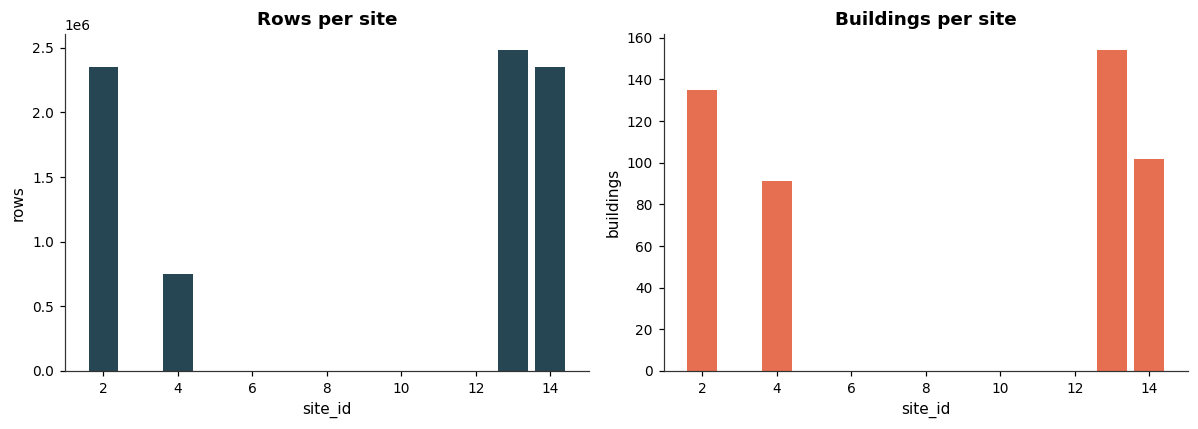

In [5]:
fig = plot_per_site_volume(df)
save_figure(fig, PLOT_DIR / "site_volume")
plt.show()


In [6]:
site_summary = (
    df.groupby("site_id")
      .agg(rows=("meter_reading", "size"),
           buildings=("building_id", "nunique"),
           meters=("meter", lambda s: s.nunique()),
           mean_reading=("meter_reading", "mean"))
      .round(2)
)
site_summary


,rows,buildings,meters,mean_reading
site_id,,,,
2,2349554,135,3,197.899994
4,746461,91,1,181.149994
13,2480548,154,3,14879.839844
14,2349638,102,4,702.469971


3. Building metadata

Primary use is the biggest single moderator of consumption. Lodging and Healthcare
operate around the clock so they dominate base load; Education has the strongest
weekday vs. weekend signal. Square footage is right-skewed across all uses, so we
log-transform it as a feature.

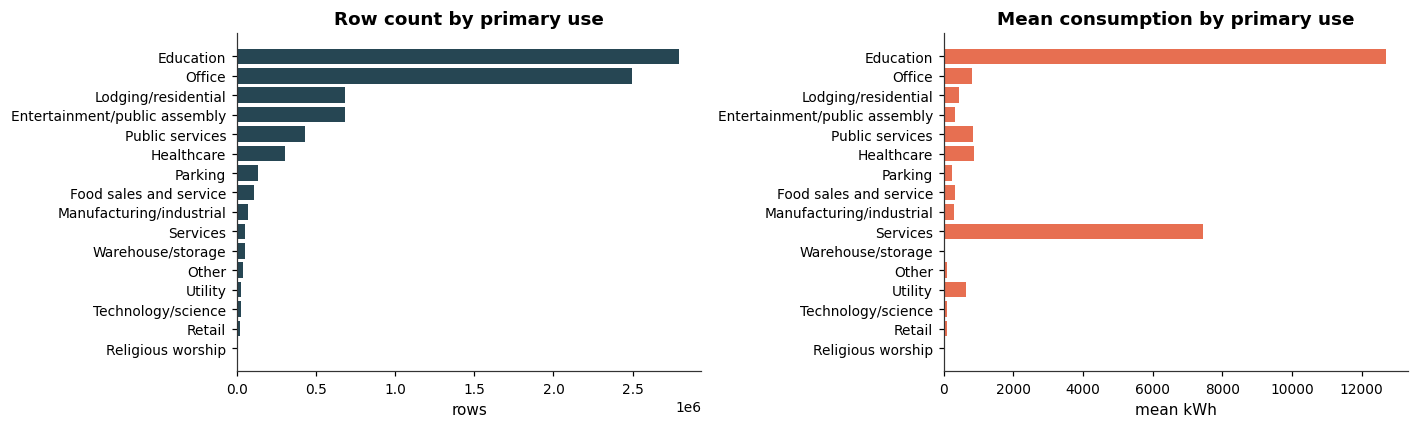

In [7]:
fig = plot_primary_use_breakdown(df)
save_figure(fig, PLOT_DIR / "primary_use_breakdown")
plt.show()


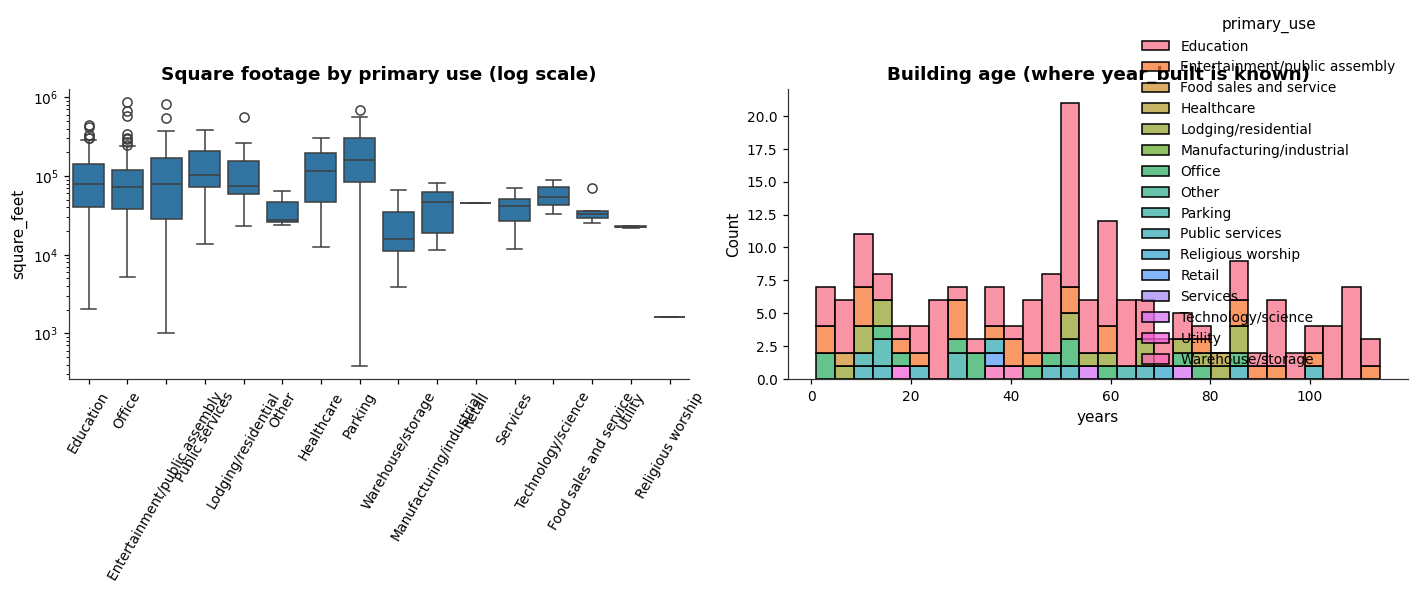

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(
    data=meta[meta["site_id"].isin(cfg.data.site_subset)],
    x="primary_use", y="square_feet",
    order=meta["primary_use"].value_counts().index, ax=axes[0],
)
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=60)
axes[0].set_title("Square footage by primary use (log scale)")
axes[0].set_xlabel("")

age_df = meta[meta["site_id"].isin(cfg.data.site_subset)].dropna(subset=["year_built"]).copy()
age_df["building_age"] = cfg.data.reference_year - age_df["year_built"]
sns.histplot(data=age_df, x="building_age", hue="primary_use",
             multiple="stack", ax=axes[1], bins=30)
axes[1].set_title("Building age (where year_built is known)")
axes[1].set_xlabel("years")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "metadata_breakdown")
plt.show()


4. Missingness

Two kinds of missingness matter for us. Building metadata is missing at fixed
rates (year_built about 60%, floor_count about 75%) — we impute or drop these
before training. Weather columns have small site-by-site gaps that we forward-fill
per site. The plot below covers the merged frame, so weather missingness is what
survives the per-site interpolation.

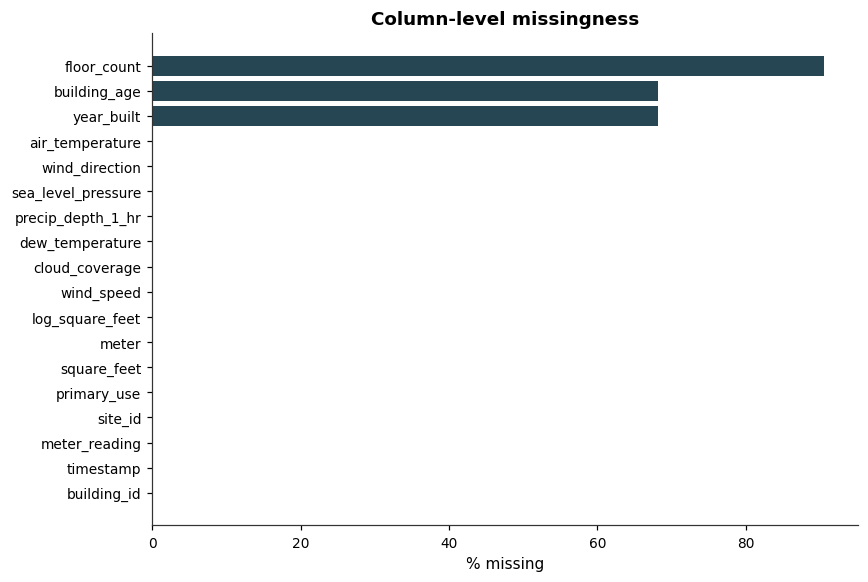

In [9]:
fig = plot_missingness(df)
save_figure(fig, PLOT_DIR / "missingness")
plt.show()


In [10]:
weather_missing = (
    weather.set_index(["site_id", "timestamp"])
           .isna().groupby("site_id").mean()
           .round(3)
)
weather_missing.loc[cfg.data.site_subset]


,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
site_id,,,,,,,
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0


5. Target distribution

`meter_reading` is heavily right-skewed: most buildings sit in a narrow band, but
a few large facilities (data centres, hospitals) consume orders of magnitude more
than the median. We train on `log1p(y)` and report metrics on the raw scale —
this is the standard transform for the ASHRAE benchmark.

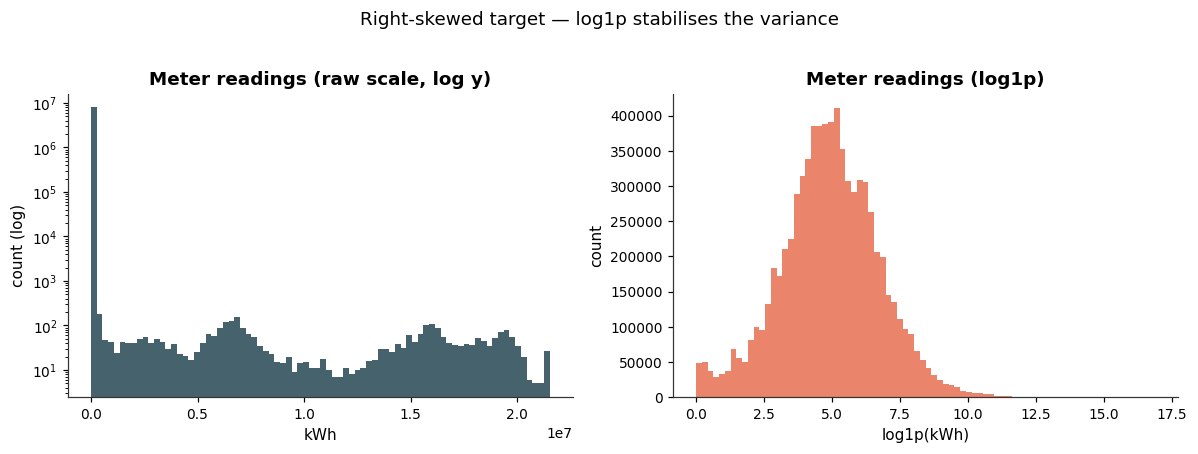

In [11]:
fig = plot_target_distribution(df)
save_figure(fig, PLOT_DIR / "target_distribution")
plt.show()


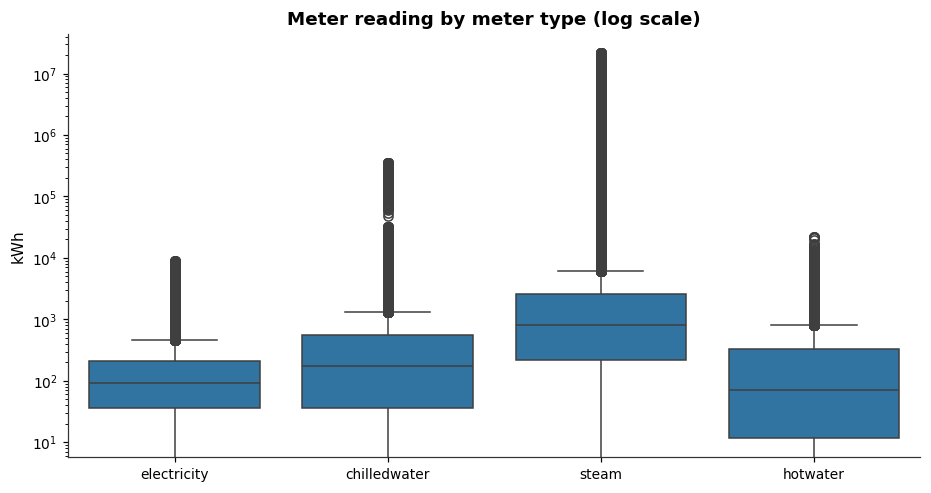

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df.assign(meter_name=df["meter"].map({0: "electricity", 1: "chilledwater",
                                                2: "steam", 3: "hotwater"})),
    x="meter_name", y="meter_reading", ax=ax,
    order=["electricity", "chilledwater", "steam", "hotwater"],
)
ax.set_yscale("log")
ax.set_title("Meter reading by meter type (log scale)")
ax.set_xlabel("")
ax.set_ylabel("kWh")
save_figure(fig, PLOT_DIR / "target_by_meter")
plt.show()


6. Meter-type breakdown

Meter type matters as much as primary use. Hot water and steam meters are
notoriously noisy in this dataset — Miller et al. (2022) reported error rates
above 60% on hot water in the original competition.

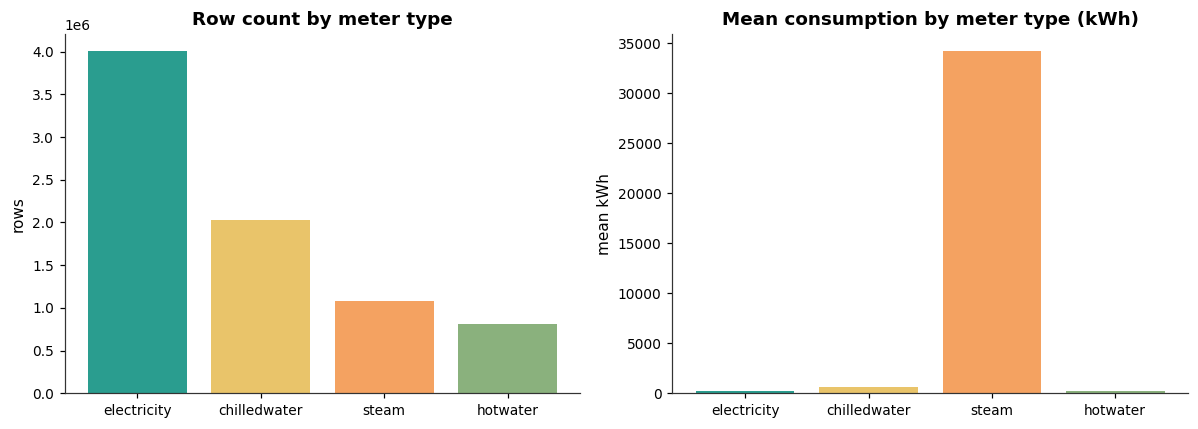

In [13]:
fig = plot_meter_breakdown(df)
save_figure(fig, PLOT_DIR / "meter_breakdown")
plt.show()


In [14]:
meter_x_use = (
    df.assign(meter_name=df["meter"].map({0: "electricity", 1: "chilledwater",
                                           2: "steam", 3: "hotwater"}))
      .groupby(["primary_use", "meter_name"], observed=True)["meter_reading"]
      .mean().unstack("meter_name").fillna(0).round(1)
)
meter_x_use


meter_name,chilledwater,electricity,hotwater,steam
primary_use,,,,
Education,953.000000,265.000000,230.800003,129629.000000
Entertainment/public assembly,427.799988,167.699997,375.600006,1257.000000
Food sales and service,424.899994,95.900002,87.099998,911.500000
Healthcare,990.200012,241.800003,364.000000,2070.199951
Lodging/residential,305.899994,121.099998,65.099998,1747.900024
Manufacturing/industrial,0.000000,111.900002,0.000000,620.700012
Office,356.899994,167.300003,305.200012,3352.600098
Other,0.000000,23.400000,0.000000,267.799988
Parking,10.200000,57.900002,0.000000,1431.099976


7. Temporal patterns

Hour-of-day and day-of-week dominate the temporal signal. Education and Office
show clear weekday-vs-weekend differences; Lodging and Healthcare are flatter.

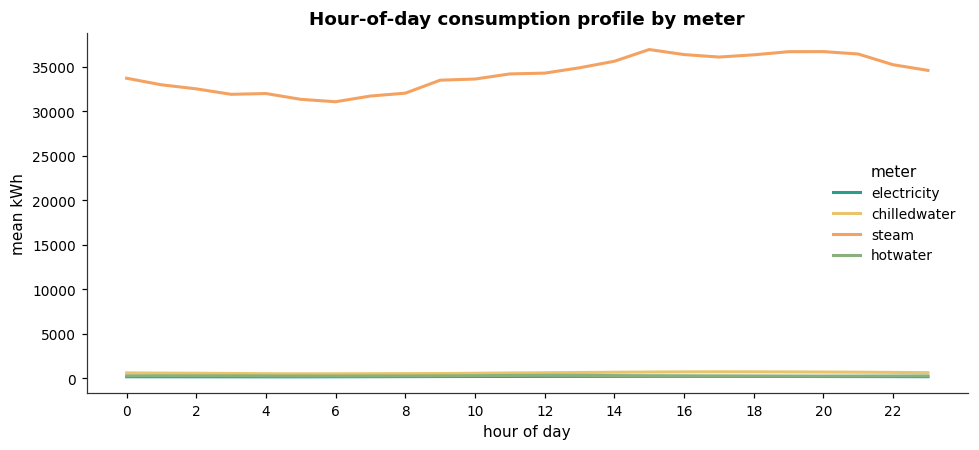

In [15]:
fig = plot_hourly_profile(df)
save_figure(fig, PLOT_DIR / "hourly_profile")
plt.show()


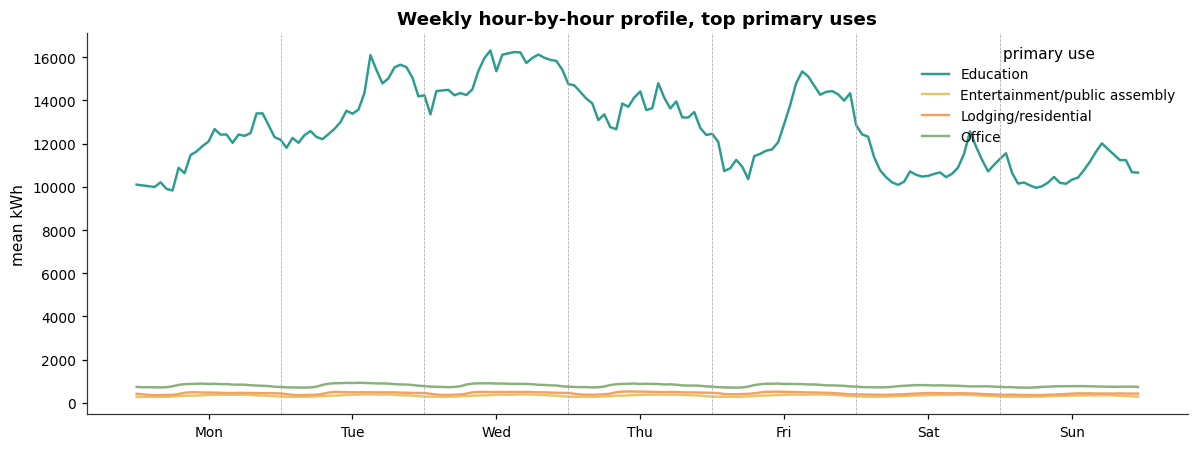

In [16]:
fig = plot_weekly_profile(df)
save_figure(fig, PLOT_DIR / "weekly_profile")
plt.show()


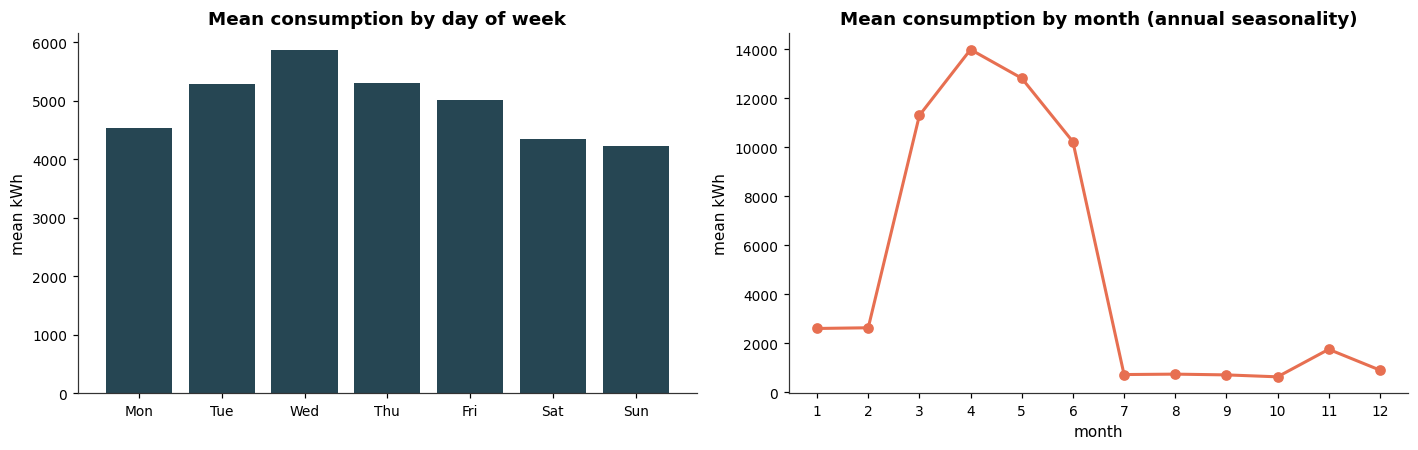

In [17]:
work = df[["timestamp", "meter_reading"]].copy()
work["dayofweek"] = pd.DatetimeIndex(work["timestamp"]).dayofweek
work["month"] = pd.DatetimeIndex(work["timestamp"]).month

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
dow = work.groupby("dayofweek")["meter_reading"].mean()
axes[0].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
            dow.values, color=PRIMARY)
axes[0].set_title("Mean consumption by day of week")
axes[0].set_ylabel("mean kWh")

mn = work.groupby("month")["meter_reading"].mean()
axes[1].plot(mn.index, mn.values, marker="o", color=ACCENT, linewidth=2)
axes[1].set_xticks(range(1, 13))
axes[1].set_title("Mean consumption by month (annual seasonality)")
axes[1].set_xlabel("month")
axes[1].set_ylabel("mean kWh")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "temporal_aggregates")
plt.show()


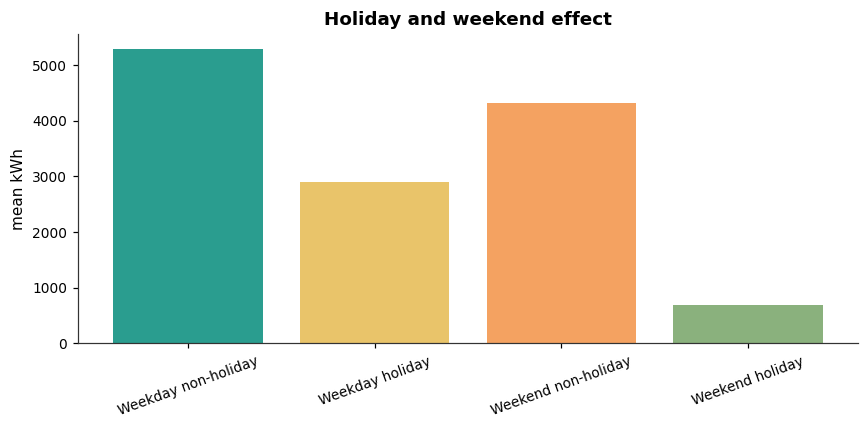

In [18]:
import holidays
us_h = holidays.country_holidays("US", years=[2016])
work["is_holiday"] = pd.DatetimeIndex(work["timestamp"]).normalize().isin(us_h.keys()).astype(int)
work["is_weekend"] = (work["dayofweek"] >= 5).astype(int)

cmp = work.groupby(["is_weekend", "is_holiday"])["meter_reading"].mean().reset_index()
cmp["bucket"] = cmp.apply(
    lambda r: ("Weekday holiday" if r["is_holiday"] and not r["is_weekend"]
               else "Weekend holiday" if r["is_holiday"] and r["is_weekend"]
               else "Weekend non-holiday" if r["is_weekend"]
               else "Weekday non-holiday"),
    axis=1,
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cmp["bucket"], cmp["meter_reading"], color=SUPPORT[:len(cmp)])
ax.set_title("Holiday and weekend effect")
ax.set_ylabel("mean kWh")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
save_figure(fig, PLOT_DIR / "holiday_weekend_effect")
plt.show()


8. Weather and the U-shaped response

Building energy use has a non-linear relationship with temperature: HVAC fights
both the heat and the cold, so demand is lowest at moderate temperatures and rises
at both extremes. That is why we add `temp_squared` as a feature for the linear
models — they cannot recover this curve from a raw temperature column on their own.

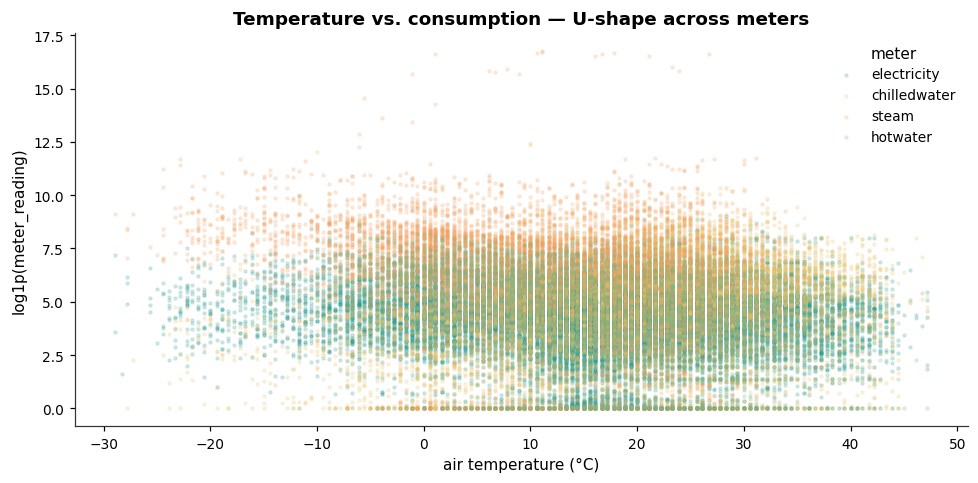

In [19]:
fig = plot_temperature_vs_consumption(df)
save_figure(fig, PLOT_DIR / "temperature_u_shape")
plt.show()


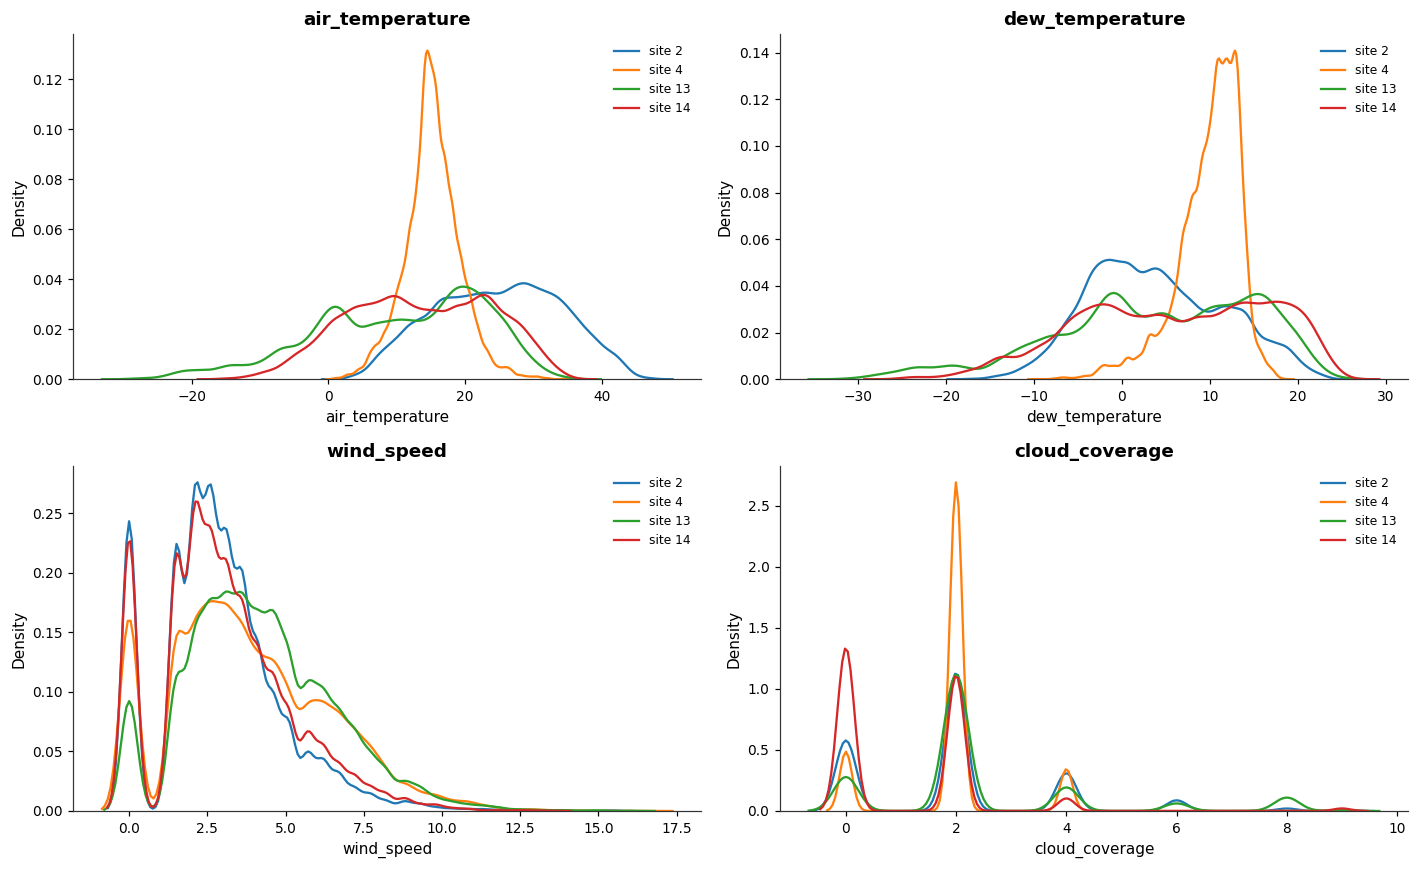

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
weather_cols = ["air_temperature", "dew_temperature", "wind_speed", "cloud_coverage"]
for ax, col in zip(axes.ravel(), weather_cols):
    if col not in df.columns:
        continue
    for s in cfg.data.site_subset:
        sub = df[df["site_id"] == s][col].dropna()
        if len(sub) > 0:
            sns.kdeplot(sub.sample(min(len(sub), 50_000), random_state=42),
                        label=f"site {s}", ax=ax, fill=False, common_norm=False)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, PLOT_DIR / "weather_distributions")
plt.show()


9. Sample time series

Picking representative buildings from each main primary use shows what we are
trying to predict. Education has weekday cycles, Lodging is flatter, Office shows
strong working-hour structure.

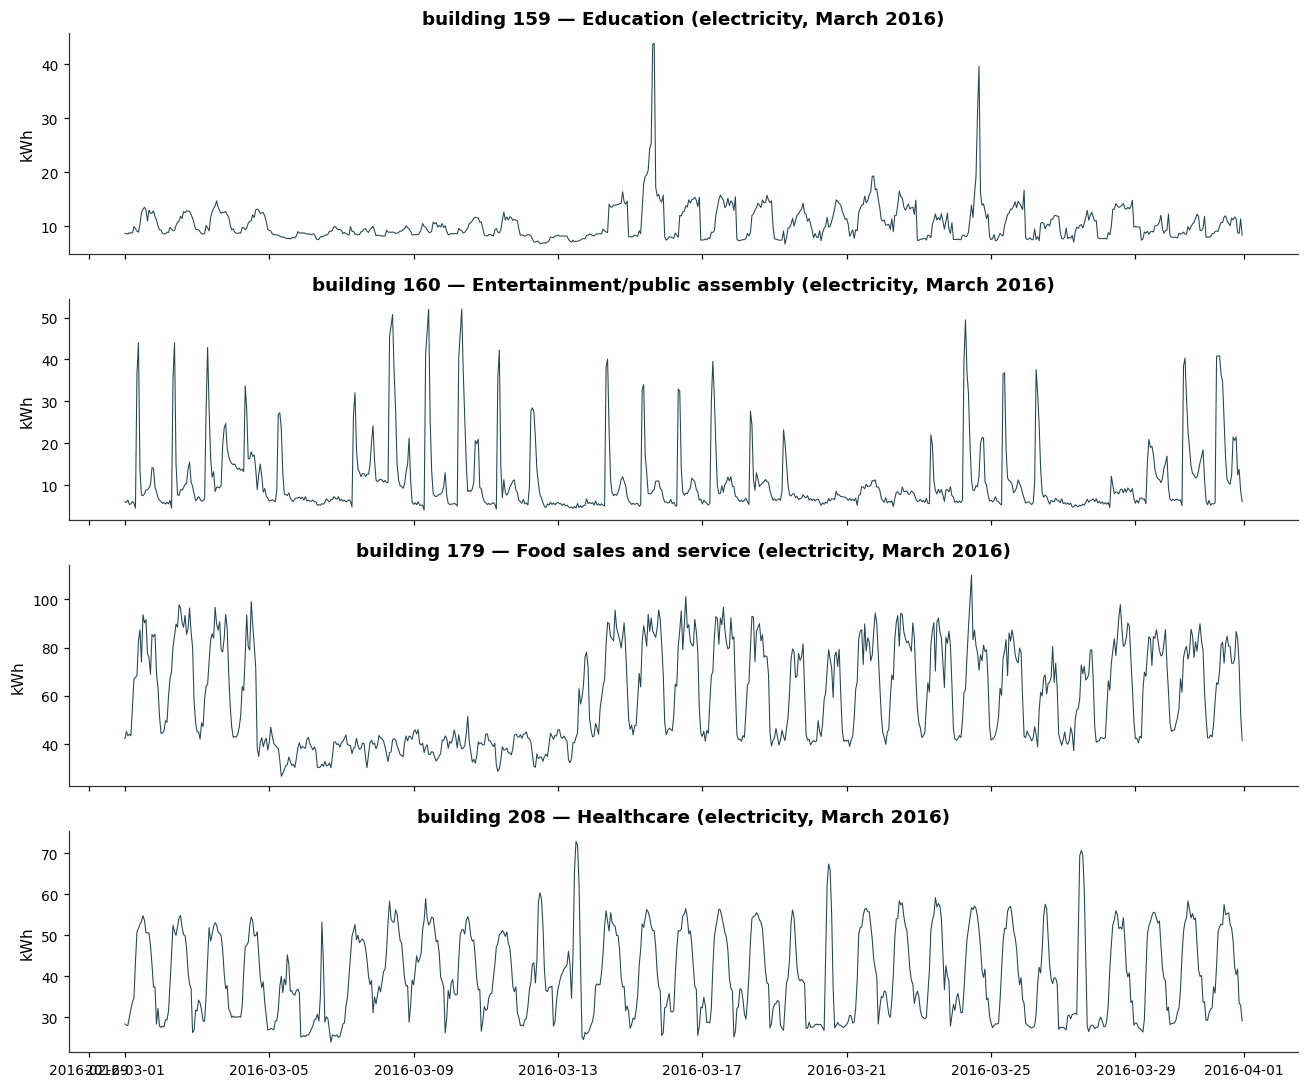

In [21]:
sample_buildings = (
    meta[meta["site_id"].isin(cfg.data.site_subset)]
        .groupby("primary_use", observed=True)["building_id"]
        .first()
        .head(4)
        .tolist()
)

fig, axes = plt.subplots(len(sample_buildings), 1, figsize=(12, 2.5 * len(sample_buildings)),
                         sharex=True)
for ax, bid in zip(np.atleast_1d(axes), sample_buildings):
    sub = df[(df["building_id"] == bid) & (df["meter"] == 0)].sort_values("timestamp")
    sub = sub[(sub["timestamp"] >= "2016-03-01") & (sub["timestamp"] < "2016-04-01")]
    if len(sub):
        ax.plot(sub["timestamp"], sub["meter_reading"], color=PRIMARY, linewidth=0.7)
        use = meta.loc[meta["building_id"] == bid, "primary_use"].iloc[0]
        ax.set_title(f"building {bid} — {use} (electricity, March 2016)")
        ax.set_ylabel("kWh")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "sample_time_series")
plt.show()


10. Outliers and zero-streaks

Most extreme readings are real (a hospital does pull 50,000+ kWh during peak
load). The cleaning step caps per-meter readings at the 99.9th percentile rather
than dropping them, and removes zero-streaks of 48 consecutive hours or more
because those are meter outages, not real zero consumption.

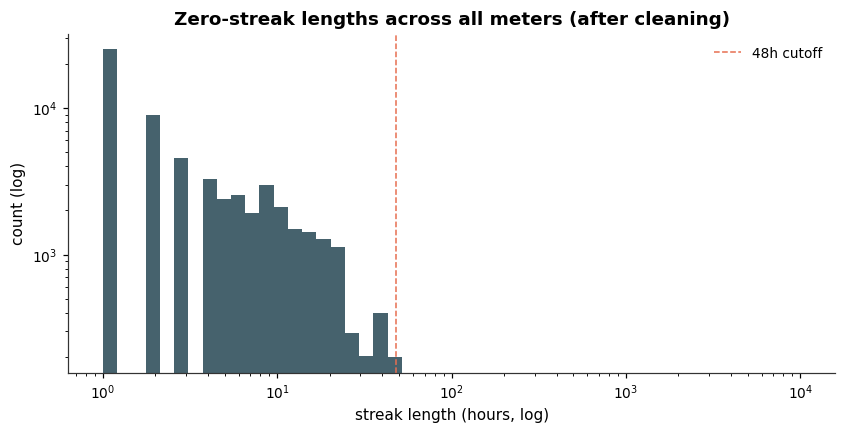

In [22]:
streak_lengths = []
for (bid, m), grp in df.sort_values(["building_id", "meter", "timestamp"]).groupby(
        ["building_id", "meter"], observed=True):
    s = (grp["meter_reading"] == 0).astype(int).to_numpy()
    if s.sum() == 0:
        continue
    runs = np.diff(np.where(np.concatenate([[1], np.diff(s) != 0, [1]]))[0])
    zero_runs = runs[s[np.where(np.concatenate([[1], np.diff(s) != 0, [1]]))[0][:-1]] == 1]
    streak_lengths.extend(zero_runs.tolist())

streak_lengths = np.array(streak_lengths)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(streak_lengths, bins=np.logspace(0, 4, 50), color=PRIMARY, alpha=0.85)
ax.axvline(48, color=ACCENT, linestyle="--", linewidth=1, label="48h cutoff")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Zero-streak lengths across all meters (after cleaning)")
ax.set_xlabel("streak length (hours, log)")
ax.set_ylabel("count (log)")
ax.legend()
save_figure(fig, PLOT_DIR / "zero_streaks")
plt.show()


In [23]:
top_outliers = (
    df.groupby("building_id")["meter_reading"]
      .max().sort_values(ascending=False).head(15)
      .reset_index()
      .merge(meta[["building_id", "primary_use", "square_feet"]], on="building_id")
)
top_outliers


,building_id,meter_reading,primary_use,square_feet
0,1099,2.151379e+07,Education,332884.0
1,1088,3.489076e+05,Education,287594.0
2,1168,1.278750e+05,Office,577101.0
3,1197,1.277602e+05,Services,50552.0
4,1159,9.822603e+04,Office,671507.0
5,1148,7.583848e+04,Office,861524.0
6,1156,3.826018e+04,Education,259989.0
7,1107,3.794419e+04,Education,184098.0
8,1154,3.633808e+04,Lodging/residential,262156.0
9,1284,3.187264e+04,Education,442438.0


11. Train / validation split

We use the proposal's split: January through September 2016 for training, October
through December for validation. The plot below shows the boundary, with a sample
of three meters' raw readings.

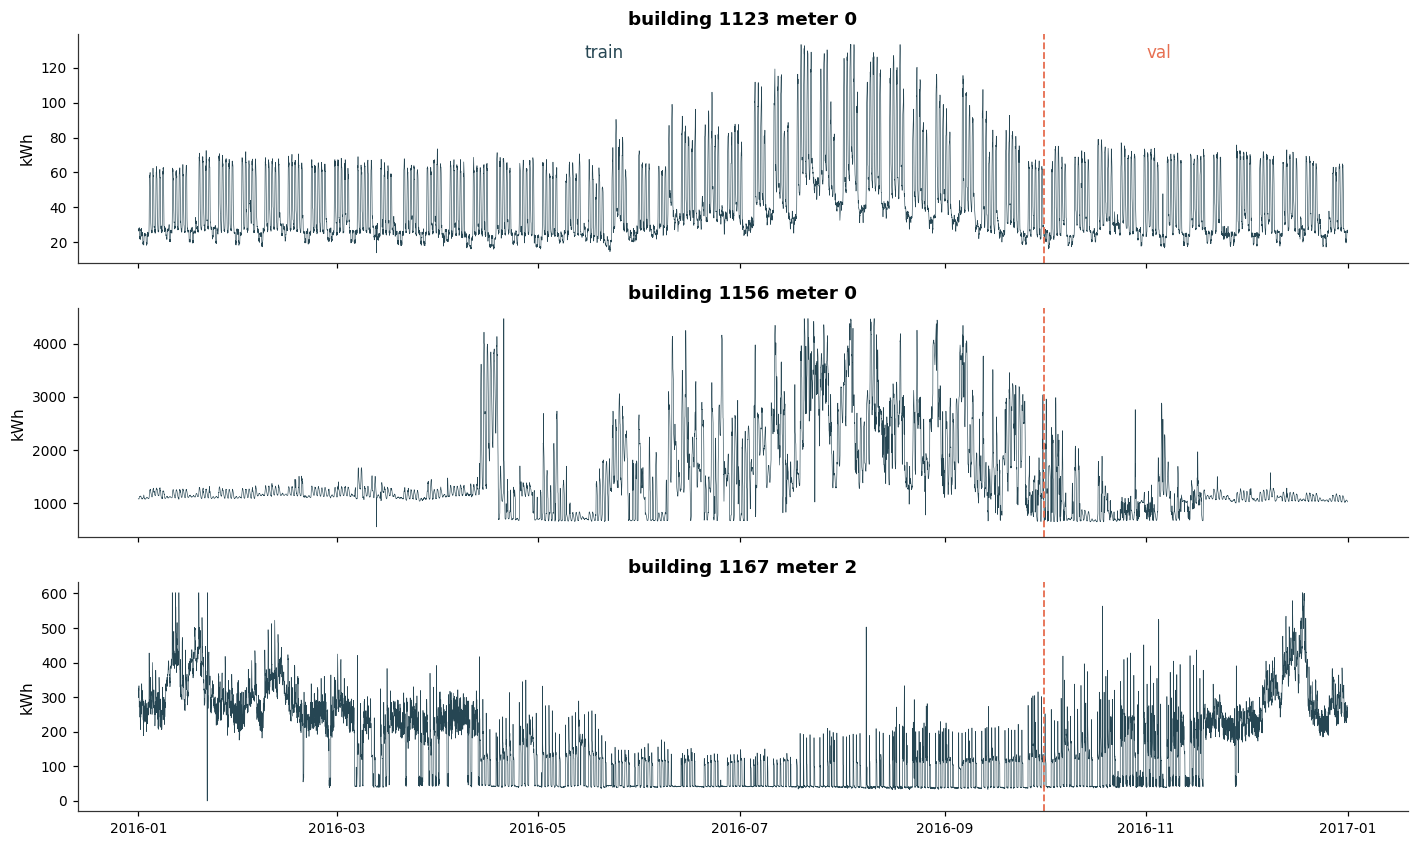

In [24]:
sample_meters = df.groupby(["building_id", "meter"], observed=True).size().sort_values(
    ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(len(sample_meters), 1, figsize=(13, 2.6 * len(sample_meters)),
                         sharex=True)
for ax, (bid, m) in zip(np.atleast_1d(axes), sample_meters):
    sub = df[(df["building_id"] == bid) & (df["meter"] == m)].sort_values("timestamp")
    ax.plot(sub["timestamp"], sub["meter_reading"], color=PRIMARY, linewidth=0.4)
    ax.axvline(pd.Timestamp("2016-10-01"), color=ACCENT, linestyle="--", linewidth=1.2)
    ax.set_title(f"building {bid} meter {m}")
    ax.set_ylabel("kWh")
axes[0].text(pd.Timestamp("2016-05-15"), axes[0].get_ylim()[1] * 0.9, "train",
             color=PRIMARY, fontsize=11)
axes[0].text(pd.Timestamp("2016-11-01"), axes[0].get_ylim()[1] * 0.9, "val",
             color=ACCENT, fontsize=11)
plt.tight_layout()
save_figure(fig, PLOT_DIR / "train_val_split")
plt.show()


Takeaways

- Target is heavily right-skewed; `log1p` is the standard transform.
- Primary use and meter type drive most of the cross-building variance.
- The temporal signal is layered: hour-of-day, day-of-week, holiday, season.
- Temperature induces a U-shaped response, so linear models need an explicit
`temp_squared` feature.
- Hot water and steam meters are noisier than electricity and chilled water; we
should expect those to be the hardest to predict.
- The Oct–Dec validation split is realistic — winter introduces heating load that
is mostly absent from a Jan–Sep training window for warm-climate sites.